# Pandas Workshop für Neurobiolog:innen

**Datensatz:** simulierte elektrophysiologische Messungen von Neuronen aus verschiedenen Hirnregionen, Genotypen und Behandlungsgruppen.

Ziel: Nach diesem Workshop könnt ihr eigene Messdaten einlesen, filtern, gruppieren und erste Zusammenfassungen berechnen — die täglichen Handgriffe im Datenalltag.

**Ablauf:**
1. Daten einlesen & anschauen
2. Spalten & Zeilen auswählen, filtern
3. Neue Spalten berechnen
4. **`groupby` — der Kern des Workshops**
5. Kurzer Ausblick: Plotten
6. Übungsaufgaben


## 1. Daten einlesen & anschauen

Wir laden Messdaten von Neuronen: Feuerrate (Hz) und Spine-Dichte (Anzahl dendritischer Spines pro µm), gemessen in drei Hirnregionen, zwei Genotypen (Wildtyp vs. Knockout eines Gens) und drei Behandlungsbedingungen.


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('neuronen_daten.csv')
df.head()

C:\Users\Chris\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Chris\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,neuron_id,tier_id,hirnregion,genotyp,behandlung,replikat,feuerrate_hz,spine_density,zelle_ueberlebt
0,N0101,T034,Amygdala,Knockout_GeneX,Stress_akut,5,6.66,8.56,1
1,N0091,T031,Amygdala,Knockout_GeneX,Kontrolle,1,6.15,6.64,1
2,N0093,T031,Amygdala,Knockout_GeneX,Kontrolle,3,3.08,11.96,1
3,N0090,T030,Amygdala,WT,Deprivation,6,3.98,10.46,1
4,N0102,T034,Amygdala,Knockout_GeneX,Stress_akut,6,5.73,6.43,1


**Spaltenübersicht:**

| Spalte | Bedeutung |
|---|---|
| `neuron_id` | eindeutige ID pro gemessenem Neuron |
| `tier_id` | Tier, von dem das Neuron stammt (mehrere Neurone pro Tier) |
| `hirnregion` | Hippocampus, Präfrontaler Cortex, Amygdala |
| `genotyp` | WT oder Knockout_GeneX |
| `behandlung` | Kontrolle, Stress_akut, Deprivation |
| `replikat` | Replikat-Nummer innerhalb der Kombination |
| `feuerrate_hz` | gemessene Feuerrate in Hz |
| `spine_density` | Spine-Dichte (Maß für synaptische Konnektivität) |
| `zelle_ueberlebt` | 1 = Zelle hat Messung überlebt, 0 = nicht |


In [2]:
# Wie viele Zeilen/Spalten haben wir?
df.shape

(108, 9)

In [3]:
# Datentypen und fehlende Werte auf einen Blick
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   neuron_id        108 non-null    object 
 1   tier_id          108 non-null    object 
 2   hirnregion       108 non-null    object 
 3   genotyp          108 non-null    object 
 4   behandlung       108 non-null    object 
 5   replikat         108 non-null    int64  
 6   feuerrate_hz     108 non-null    float64
 7   spine_density    102 non-null    float64
 8   zelle_ueberlebt  108 non-null    int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 7.7+ KB


In [4]:
# Deskriptive Statistik für alle numerischen Spalten
df.describe()

,replikat,feuerrate_hz,spine_density,zelle_ueberlebt
count,108.000000,108.000000,102.000000,108.000000
mean,3.500000,4.653426,10.235196,0.944444
std,1.715787,2.060959,2.739289,0.230129
min,1.000000,0.100000,4.000000,0.000000
25%,2.000000,3.342500,8.500000,1.000000
50%,3.500000,4.545000,10.315000,1.000000
75%,5.000000,6.165000,11.892500,1.000000
max,6.000000,10.510000,18.930000,1.000000


**Hinweis:** `spine_density` hat weniger Einträge als die anderen Spalten (`.info()` zeigt es) — das sind echte fehlende Messwerte (NaN). Das kommt in echten Datensätzen ständig vor. Wir gehen später kurz darauf ein.


## 2. Spalten & Zeilen auswählen, filtern

### Eine einzelne Spalte auswählen


In [5]:
df['feuerrate_hz']

0      6.66
1      6.15
2      3.08
3      3.98
4      5.73
       ... 
103    3.62
104    7.31
105    4.81
106    3.84
107    3.57
Name: feuerrate_hz, Length: 108, dtype: float64

Das Ergebnis ist keine Tabelle mehr, sondern eine **Series** (eine einzelne Spalte mit Index).

In [6]:
# Mehrere Spalten auswählen -> Ergebnis bleibt ein DataFrame
df[['hirnregion', 'feuerrate_hz']]

,hirnregion,feuerrate_hz
0,Amygdala,6.66
1,Amygdala,6.15
2,Amygdala,3.08
3,Amygdala,3.98
4,Amygdala,5.73
...,...,...
103,Amygdala,3.62
104,Hippocampus,7.31
105,Amygdala,4.81
106,Hippocampus,3.84


### Zeilen filtern mit Bedingungen

Das ist vermutlich der wichtigste Handgriff im Alltag: "Zeig mir nur die Zeilen, die eine bestimmte Bedingung erfüllen."


In [7]:
# Nur Neurone mit hoher Feuerrate
df[df['feuerrate_hz'] > 8]

,neuron_id,tier_id,hirnregion,genotyp,behandlung,replikat,feuerrate_hz,spine_density,zelle_ueberlebt
72,N0084,T028,Amygdala,WT,Stress_akut,6,8.26,10.92,1
81,N0008,T003,Hippocampus,WT,Stress_akut,2,8.90,6.26,1
87,N0030,T010,Hippocampus,Knockout_GeneX,Stress_akut,6,10.51,5.34,1
95,N0007,T003,Hippocampus,WT,Stress_akut,1,8.27,5.56,1


In [8]:
# Nur Neurone aus dem Hippocampus
df[df['hirnregion'] == 'Hippocampus']

,neuron_id,tier_id,hirnregion,genotyp,behandlung,replikat,feuerrate_hz,spine_density,zelle_ueberlebt
11,N0003,T001,Hippocampus,WT,Kontrolle,3,5.24,11.58,1
20,N0018,T006,Hippocampus,WT,Deprivation,6,3.39,9.15,1
24,N0034,T012,Hippocampus,Knockout_GeneX,Deprivation,4,3.07,9.23,1
25,N0036,T012,Hippocampus,Knockout_GeneX,Deprivation,6,4.81,10.32,1
28,N0032,T011,Hippocampus,Knockout_GeneX,Deprivation,2,4.29,10.03,1
32,N0011,T004,Hippocampus,WT,Stress_akut,5,7.40,9.20,1
33,N0033,T011,Hippocampus,Knockout_GeneX,Deprivation,3,4.93,9.07,1
35,N0020,T007,Hippocampus,Knockout_GeneX,Kontrolle,2,4.68,6.83,1
36,N0028,T010,Hippocampus,Knockout_GeneX,Stress_akut,4,5.66,6.86,1
47,N0024,T008,Hippocampus,Knockout_GeneX,Kontrolle,6,3.38,9.44,1


### Mehrere Bedingungen kombinieren

- `&` = UND
- `|` = ODER
- Jede Einzelbedingung **muss in Klammern** stehen!


In [9]:
# Hippocampus UND Knockout-Genotyp
df[(df['hirnregion'] == 'Hippocampus') & (df['genotyp'] == 'Knockout_GeneX')]

,neuron_id,tier_id,hirnregion,genotyp,behandlung,replikat,feuerrate_hz,spine_density,zelle_ueberlebt
24,N0034,T012,Hippocampus,Knockout_GeneX,Deprivation,4,3.07,9.23,1
25,N0036,T012,Hippocampus,Knockout_GeneX,Deprivation,6,4.81,10.32,1
28,N0032,T011,Hippocampus,Knockout_GeneX,Deprivation,2,4.29,10.03,1
33,N0033,T011,Hippocampus,Knockout_GeneX,Deprivation,3,4.93,9.07,1
35,N0020,T007,Hippocampus,Knockout_GeneX,Kontrolle,2,4.68,6.83,1
36,N0028,T010,Hippocampus,Knockout_GeneX,Stress_akut,4,5.66,6.86,1
47,N0024,T008,Hippocampus,Knockout_GeneX,Kontrolle,6,3.38,9.44,1
48,N0035,T012,Hippocampus,Knockout_GeneX,Deprivation,5,4.31,10.59,1
60,N0027,T009,Hippocampus,Knockout_GeneX,Stress_akut,3,7.69,9.44,1
64,N0025,T009,Hippocampus,Knockout_GeneX,Stress_akut,1,7.16,8.76,1


In [10]:
# Kontrolle ODER Deprivation
df[(df['behandlung'] == 'Kontrolle') | (df['behandlung'] == 'Deprivation')]

,neuron_id,tier_id,hirnregion,genotyp,behandlung,replikat,feuerrate_hz,spine_density,zelle_ueberlebt
1,N0091,T031,Amygdala,Knockout_GeneX,Kontrolle,1,6.15,6.64,1
2,N0093,T031,Amygdala,Knockout_GeneX,Kontrolle,3,3.08,11.96,1
3,N0090,T030,Amygdala,WT,Deprivation,6,3.98,10.46,1
5,N0056,T019,Praefrontaler_Cortex,Knockout_GeneX,Kontrolle,2,1.79,12.79,1
6,N0089,T030,Amygdala,WT,Deprivation,5,3.45,13.37,1
...,...,...,...,...,...,...,...,...,...
102,N0006,T002,Hippocampus,WT,Kontrolle,6,4.99,NaN,1
103,N0076,T026,Amygdala,WT,Kontrolle,4,3.62,12.87,1
105,N0073,T025,Amygdala,WT,Kontrolle,1,4.81,14.62,1
106,N0013,T005,Hippocampus,WT,Deprivation,1,3.84,15.33,1


### `.loc[]` — Zeilen und Spalten gleichzeitig auswählen

`df.loc[Zeilenbedingung, Spaltenauswahl]`


In [11]:
# Nur ID und Feuerrate der Neurone mit Feuerrate > 8
df.loc[df['feuerrate_hz'] > 8, ['neuron_id', 'feuerrate_hz']]

,neuron_id,feuerrate_hz
72,N0084,8.26
81,N0008,8.90
87,N0030,10.51
95,N0007,8.27


## 3. Neue Spalten berechnen

Neue Spalten entstehen einfach durch Zuweisung — kein spezieller Befehl nötig.


In [12]:
# Beispiel: Feuerrate pro Einheit Spine-Dichte (fiktives Maß)
df['feuerrate_pro_spine'] = df['feuerrate_hz'] / df['spine_density']
df.head()

,neuron_id,tier_id,hirnregion,genotyp,behandlung,replikat,feuerrate_hz,spine_density,zelle_ueberlebt,feuerrate_pro_spine
0,N0101,T034,Amygdala,Knockout_GeneX,Stress_akut,5,6.66,8.56,1,0.778037
1,N0091,T031,Amygdala,Knockout_GeneX,Kontrolle,1,6.15,6.64,1,0.926205
2,N0093,T031,Amygdala,Knockout_GeneX,Kontrolle,3,3.08,11.96,1,0.257525
3,N0090,T030,Amygdala,WT,Deprivation,6,3.98,10.46,1,0.380497
4,N0102,T034,Amygdala,Knockout_GeneX,Stress_akut,6,5.73,6.43,1,0.891135


In [13]:
# Zusammenfassende Kennzahlen über eine ganze Spalte
print('Mittlere Feuerrate:', df['feuerrate_hz'].mean())
print('Maximale Feuerrate:', df['feuerrate_hz'].max())
print('Standardabweichung:', df['feuerrate_hz'].std())

Mittlere Feuerrate: 4.653425925925926
Maximale Feuerrate: 10.51
Standardabweichung: 2.060959381914404


## 4. `groupby` — Gruppierte Auswertungen

Das ist das mit Abstand nützlichste Werkzeug in Pandas für den Laboralltag: **Split – Apply – Combine**

1. **Split**: Die Tabelle wird anhand einer Spalte (z.B. `behandlung`) in Gruppen zerlegt
2. **Apply**: Auf jede Gruppe wird eine Funktion angewendet (z.B. Mittelwert)
3. **Combine**: Die Ergebnisse werden wieder in einer Tabelle zusammengeführt

Genau das macht ihr im Kopf, wenn ihr sagt: *"Ich nehme alle Kontrolltiere, bilde den Mittelwert der Feuerrate, dann alle Stresstiere, bilde den Mittelwert, ..."* — `groupby` automatisiert das.


In [14]:
# Was passiert, wenn wir NUR groupby aufrufen, ohne Aggregation?
df.groupby('behandlung')

Das ist noch kein Ergebnis, sondern ein **GroupBy-Objekt** — es "wartet" darauf, dass wir ihm sagen, was es mit jeder Gruppe tun soll (Mittelwert? Summe? Anzahl?).


### a) Einfachstes Beispiel: Mittlere Feuerrate pro Behandlung

In [15]:
df.groupby('behandlung')['feuerrate_hz'].mean()

behandlung
Deprivation    3.233333
Kontrolle      4.047222
Stress_akut    6.679722
Name: feuerrate_hz, dtype: float64

Gleiche Syntax funktioniert für andere Kennzahlen:

In [16]:
print(df.groupby('behandlung')['feuerrate_hz'].median())
print()
print(df.groupby('behandlung')['feuerrate_hz'].std())
print()
print(df.groupby('behandlung')['feuerrate_hz'].count())

behandlung
Deprivation    3.395
Kontrolle      3.900
Stress_akut    6.635
Name: feuerrate_hz, dtype: float64

behandlung
Deprivation    1.667090
Kontrolle      1.398549
Stress_akut    1.254909
Name: feuerrate_hz, dtype: float64

behandlung
Deprivation    36
Kontrolle      36
Stress_akut    36
Name: feuerrate_hz, dtype: int64


### b) `.size()` vs `.count()` — wie viele Proben pro Gruppe?

Wichtig, **bevor** man Statistik macht: sind die Gruppen überhaupt gleich groß?


In [17]:
# .size() zählt alle Zeilen pro Gruppe (inkl. NaNs)
df.groupby('behandlung').size()

behandlung
Deprivation    36
Kontrolle      36
Stress_akut    36
dtype: int64

In [18]:
# .count() zählt nur nicht-fehlende Werte pro Spalte
# -> hier sieht man z.B., wo spine_density NaNs hat
df.groupby('behandlung')['spine_density'].count()

behandlung
Deprivation    33
Kontrolle      35
Stress_akut    34
Name: spine_density, dtype: int64

### c) Mehrere Spalten gleichzeitig aggregieren


In [19]:
df.groupby('behandlung')[['feuerrate_hz', 'spine_density']].mean()

,feuerrate_hz,spine_density
behandlung,,
Deprivation,3.233333,11.625758
Kontrolle,4.047222,11.149143
Stress_akut,6.679722,7.944706


### d) Unterschiedliche Aggregationen pro Spalte mit `.agg()`

Manchmal will man z.B. den Mittelwert der Feuerrate, aber das Maximum der Spine-Dichte.


In [20]:
df.groupby('behandlung').agg({
    'feuerrate_hz': 'mean',
    'spine_density': 'max',
    'zelle_ueberlebt': 'sum'   # Summe von 0/1 = Anzahl überlebter Zellen
})

,feuerrate_hz,spine_density,zelle_ueberlebt
behandlung,,,
Deprivation,3.233333,18.93,33
Kontrolle,4.047222,16.90,36
Stress_akut,6.679722,11.53,33


### e) Gruppieren nach **mehreren** Spalten gleichzeitig

Das ist der Fall, den ihr in der Praxis am häufigsten braucht: *"Mittlere Feuerrate pro Hirnregion UND Genotyp"*.


In [21]:
df.groupby(['hirnregion', 'genotyp'])['feuerrate_hz'].mean()

hirnregion            genotyp       
Amygdala              Knockout_GeneX    3.878889
                      WT                5.282222
Hippocampus           Knockout_GeneX    5.285000
                      WT                6.130000
Praefrontaler_Cortex  Knockout_GeneX    3.136111
                      WT                4.208333
Name: feuerrate_hz, dtype: float64

Das Ergebnis hat einen **MultiIndex** (zwei Ebenen: Hirnregion + Genotyp). Für die Weiterverarbeitung (z.B. Plotten oder Speichern als CSV) ist es oft praktischer, wieder normale Spalten zu haben:


In [22]:
ergebnis = df.groupby(['hirnregion', 'genotyp'])['feuerrate_hz'].mean().reset_index()
ergebnis

,hirnregion,genotyp,feuerrate_hz
0,Amygdala,Knockout_GeneX,3.878889
1,Amygdala,WT,5.282222
2,Hippocampus,Knockout_GeneX,5.285000
3,Hippocampus,WT,6.130000
4,Praefrontaler_Cortex,Knockout_GeneX,3.136111
5,Praefrontaler_Cortex,WT,4.208333


### f) Kombination: gruppieren nach 3 Faktoren

Genau das, was ihr für eine echte 3-Faktoren-Auswertung (Region × Genotyp × Behandlung) braucht:


In [23]:
df.groupby(['hirnregion', 'genotyp', 'behandlung'])['feuerrate_hz'].agg(['mean', 'std', 'count']).reset_index()

,hirnregion,genotyp,behandlung,mean,std,count
0,Amygdala,Knockout_GeneX,Deprivation,1.890000,1.721511,6
1,Amygdala,Knockout_GeneX,Kontrolle,3.810000,1.291495,6
2,Amygdala,Knockout_GeneX,Stress_akut,5.936667,1.245466,6
3,Amygdala,WT,Deprivation,3.911667,0.995579,6
4,Amygdala,WT,Kontrolle,4.716667,0.669915,6
5,Amygdala,WT,Stress_akut,7.218333,0.760143,6
6,Hippocampus,Knockout_GeneX,Deprivation,4.135000,0.750566,6
7,Hippocampus,Knockout_GeneX,Kontrolle,4.250000,0.798749,6
8,Hippocampus,Knockout_GeneX,Stress_akut,7.470000,1.642681,6
9,Hippocampus,WT,Deprivation,4.901667,1.541265,6


### g) Sortieren der Gruppenergebnisse

`groupby` lässt sich problemlos mit `.sort_values()` kombinieren.


In [24]:
df.groupby('hirnregion')['feuerrate_hz'].mean().sort_values(ascending=False)

hirnregion
Hippocampus             5.707500
Amygdala                4.580556
Praefrontaler_Cortex    3.672222
Name: feuerrate_hz, dtype: float64

## 5. Kurzer Ausblick: Direkt weiterplotten

Ein `groupby`-Ergebnis lässt sich ohne Umwege plotten — praktisch für einen ersten schnellen Blick.


<Axes: title={'center': 'Mittlere Feuerrate pro Behandlung'}, xlabel='behandlung'>

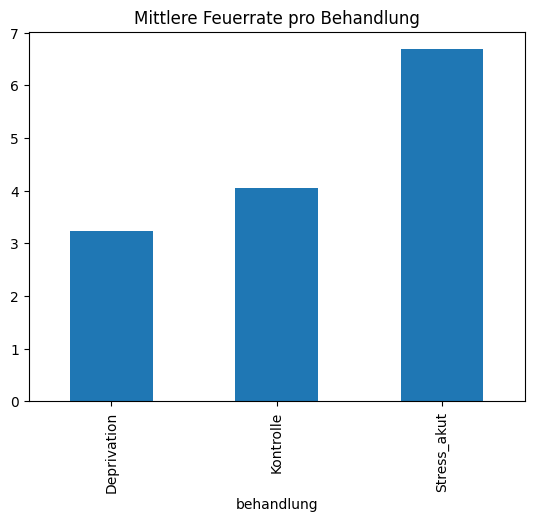

In [25]:
%matplotlib inline
df.groupby('behandlung')['feuerrate_hz'].mean().plot(kind='bar', title='Mittlere Feuerrate pro Behandlung')

## 6. Übungsaufgaben

Versucht die folgenden Aufgaben selbst — nutzt dafür `df`. Lösungen stehen jeweils darunter (erst schauen, wenn ihr selbst probiert habt!).

### Aufgabe 1
Berechnet die **mittlere Spine-Dichte pro Genotyp**.


In [ ]:
# Euer Code hier


<details>
<summary>Lösung anzeigen</summary>

```python
df.groupby('genotyp')['spine_density'].mean()
```
</details>


### Aufgabe 2
Filtert zunächst alle Zeilen, bei denen die Zelle **überlebt hat** (`zelle_ueberlebt == 1`), und berechnet dann die mittlere Feuerrate pro Hirnregion — sortiert absteigend nach Feuerrate.


In [ ]:
# Euer Code hier


<details>
<summary>Lösung anzeigen</summary>

```python
df_survived = df[df['zelle_ueberlebt'] == 1]
df_survived.groupby('hirnregion')['feuerrate_hz'].mean().sort_values(ascending=False)
```
</details>


### Aufgabe 3 (etwas anspruchsvoller)
Berechnet für jede Kombination aus `genotyp` und `behandlung` sowohl den Mittelwert als auch die Anzahl der Neurone (`count`) für die Feuerrate. Nutzt `.reset_index()`, damit das Ergebnis eine normale Tabelle wird.


In [ ]:
# Euer Code hier


<details>
<summary>Lösung anzeigen</summary>

```python
df.groupby(['genotyp', 'behandlung'])['feuerrate_hz'].agg(['mean', 'count']).reset_index()
```
</details>


## Zusammenfassung

| Aufgabe | Befehl |
|---|---|
| Daten einlesen | `pd.read_csv()` |
| Überblick verschaffen | `.head()`, `.info()`, `.describe()` |
| Spalte auswählen | `df['spalte']` |
| Zeilen filtern | `df[df['spalte'] > wert]` |
| Neue Spalte berechnen | `df['neu'] = ...` |
| Gruppieren & aggregieren | `df.groupby('spalte')['wert'].mean()` |
| Mehrere Aggregationen | `.agg(['mean', 'std', 'count'])` |
| MultiIndex auflösen | `.reset_index()` |

**Nächste Schritte:** `merge()` (mehrere Tabellen zusammenführen, z.B. Metadaten pro Tier), `pivot_table()` (Kreuztabellen), und die direkte Anbindung an `matplotlib`/`seaborn` für publikationsreife Plots.
